<a href="https://colab.research.google.com/github/moloruns/Olorunsola_DSPN_S26/blob/master/Exercise11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds.


-----
## 1. Data, Plotting, and Train/Test Sets (2 points)
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [2]:
library(tidyverse)
library(class)
dat <- diamonds
dat$price_bin <- if_else(dat$price > mean(dat$price), 1, 0)
dat$price_bin <- as.factor(dat$price_bin)
dat <- dat |>
  select(carat, depth, table, x, y, price_bin)

head(dat)
dim(dat)


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

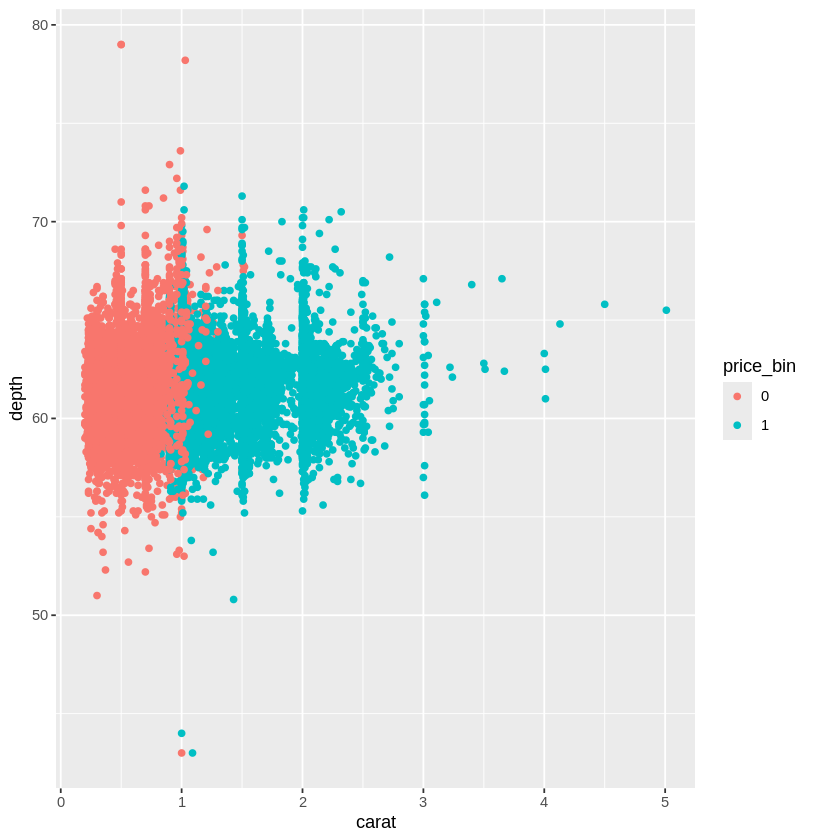

In [3]:
dat |>
  ggplot(aes(x = carat, y = depth, color = price_bin)) +
  geom_point()


Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict diabetes diagnosis? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> * Based on the scatterplot, I think kNN will perform fairly well as the two price groups are decently separated; most low-price diamonds cluster at lower carat values, and most high-price diamonds cluster at higher carat values.
> * `carat`

### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [6]:
set.seed(2023)

n_test <- 0.3*nrow(dat)

test.id <- sample(1:nrow(dat), n_test)
train.id <- !(1:nrow(dat) %in% test.id)

dat.test <- dat[test.id, ]
dat.train <- dat[train.id, ]

head(dat.test)
head(dat.train)
dim(dat.test)
dim(dat.train)


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.22,62.3,56.0,6.81,6.84,1
1.57,62.3,56.0,7.48,7.41,1
1.11,62.4,57.7,6.57,6.64,1
0.42,60.6,57.0,4.82,4.85,0
0.32,62.6,55.0,4.39,4.36,0
0.90,62.7,58.0,6.06,6.15,1


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0
0.24,62.3,57,3.95,3.98,0


[1] 16182     6

[1] 37758     6

-----
## 2. KNN (3 points)
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [8]:
set.seed(2023)
train.pred <- cbind(dat.train$carat, dat.train$depth)
train.price <- dat.train$price_bin
test.pred <- cbind(dat.test$carat, dat.test$depth)

test.price.knn <- knn(train.pred, test.pred, train.price, k = 3)

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [15]:
conf.mat <- data.frame(predicted = test.price.knn,
                       actual = dat.test$price_bin)
table(conf.mat)

test.error <- mean(conf.mat$predicted != conf.mat$actual)
cat("Test error = ", test.error*100, "%")


         actual
predicted    0    1
        0 9707  316
        1  539 5620

Test error =  5.283648 %

How did your model perform?
> Given that we had an error rate of ~5.28%, the model performed quite well.


Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [16]:
set.seed(2023)
train.pred <- cbind(dat.train$carat,
                    dat.train$depth,
                    dat.train$table,
                    dat.train$x,
                    dat.train$y)

test.pred <- cbind(dat.test$carat,
                    dat.test$depth,
                    dat.test$table,
                    dat.test$x,
                    dat.test$y)

test.price.knn <- knn(train.pred, test.pred, train.price, k = 3)

conf.mat <- data.frame(predicted = test.price.knn,
                       actual = dat.test$price_bin)
table(conf.mat)

test.error <- mean(conf.mat$predicted != conf.mat$actual)
cat("Test error = ", test.error*100, "%")


         actual
predicted    0    1
        0 9728  391
        1  518 5545

Test error =  5.617353 %

Did your model predictions improve?
> While the model still performed well overall, predictions here did not improve (slightly worse error rate of 5.61%).


-----
## 3. For loop (3 points)

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [17]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [18]:
for (k in seq(1:30)) {
    knn_fits  <- knn(train.pred, test.pred, train.price, k = k)

    #overall error
    conf_df  <- data.frame(predictions = knn_fits,
                           actual = dat.test$price_bin)
    output$error[k]  <- mean(conf_df$predictions != conf_df$actual)*100

}
head(output)

,k,error
,<int>,<dbl>
1,1,6.507230
2,2,6.655543
3,3,5.642071
4,4,5.592634
5,5,5.326906
6,6,5.333086


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


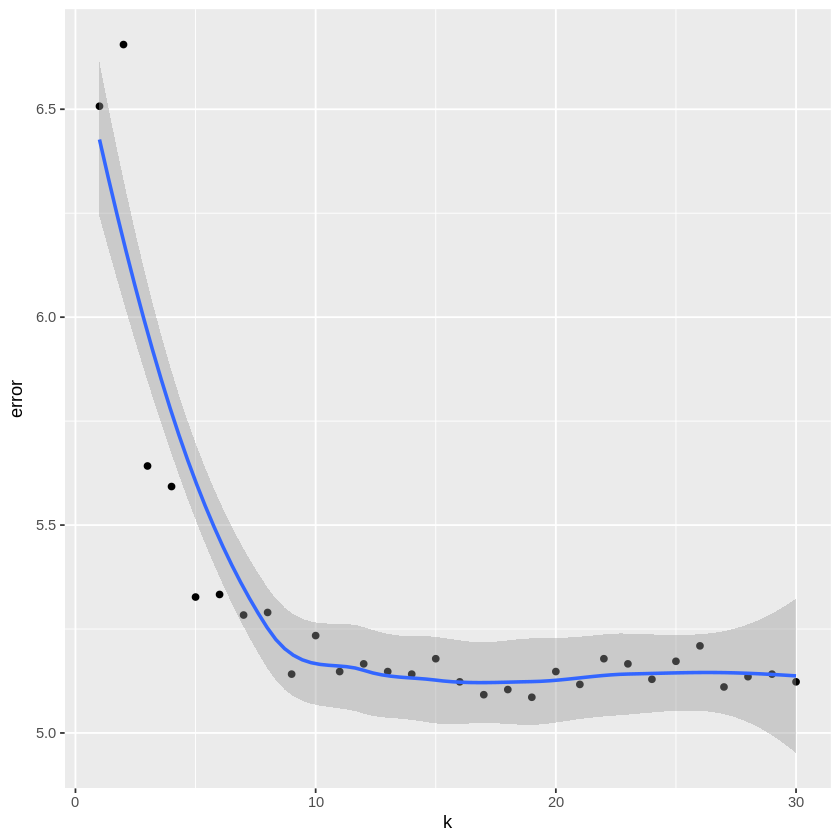

In [19]:
output |>
  ggplot(aes(x = k, y = error)) +
  geom_point() +
  geom_smooth()

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> As k increases, the model's error rate decreases. Though, the improvement is most dramatic from k = 1 to (around) k = 9, after which the error rate plateaus and any further increases in k yield negligible gains. As such, I would choose k = 9 as the optimal value because it sits right at the point where the error rate has stabilized around its minimum (approximately 5.33%). Lastly, with this selection, this doesn't do *much* in terms of improving test error (as it was already around 5.3).



-----
## 4. Standardizing predictors (2 points)

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [48]:
set.seed(2023)

# standardize besides outcome
dat2 <- data.frame(scale(dat[,-6]))

# train/test sets with scaled predictors
dat2.test <- dat2[test.id, ]
dat2.train <- dat2[train.id, ]

# knn
train.pred <- cbind(dat2.train$carat, dat2.train$depth)
test.pred <- cbind(dat2.test$carat, dat2.test$depth)

test.price.knn <- knn(train.pred, test.pred, train.price, k = 9)

conf.mat <- data.frame(predicted = test.price.knn,
                       actual = dat.test$price_bin) # unscaled outcome
table(conf.mat)
test.error <- mean(conf.mat$predicted != conf.mat$actual)
cat("Test error = ", test.error*100, "%")

         actual
predicted    0    1
        0 9711  298
        1  535 5638

Test error =  5.147695 %

What impact did rescaling the data have on your error rate?
> We yield a better error rate with this model (~5.15%).


**DUE:** 11:59pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> no
>
>


**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.